# Función de Activación = ReLU, Coeficiente R2, HOLD-Out

In [1]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from tqdm import tqdm
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device="cuda"
else:
    device="cpu"
device

'cpu'

In [2]:
data = pd.read_csv('./structuralparameters-vs-capacities-5000mofs.csv', index_col=False, header=0)
data

,usablegc,usablevc,density,porosity,Ri,SSA,SPV,du,metalw,metala
0,0.2294,0.003505,1.525,0.04,2.22,632,0.026,289.0,19.449,3.704
1,0.1965,0.003082,1.566,0.02,1.77,529,0.013,289.0,19.449,3.704
2,1.3542,0.013027,0.949,0.30,5.70,3024,0.316,217.0,24.053,7.143
3,0.3773,0.004750,1.255,0.04,2.27,1002,0.032,233.0,15.330,2.439
4,0.4118,0.005179,1.253,0.04,2.41,1085,0.032,465.0,15.330,2.439
...,...,...,...,...,...,...,...,...,...,...
4995,0.1503,0.002866,1.905,0.02,2.20,377,0.011,313.0,31.873,5.882
4996,0.2563,0.002970,1.156,0.08,3.92,598,0.069,145.0,9.378,3.279
4997,0.1684,0.002585,1.533,0.06,2.48,479,0.039,201.0,24.548,2.222
4998,0.1743,0.002776,1.590,0.06,2.49,433,0.038,401.0,25.770,2.222


In [3]:
limites_tabla = pd.read_csv('./limits_5000mofs.csv', index_col=False, header=0)
limites_tabla

,Variable,Units,lowlimit,highlimit
0,usablegc,(wt.%),0.000001,15.00
1,usablevc,(kg/L),0.000001,0.06
2,density,(kg/L),0.100000,5.00
3,porosity,(dimensionless),0.000100,0.90
4,R_i,(angstroms),1.000000,40.00
5,ssa,(m^2/g),100.000000,10000.00
6,specificporevolume,(cm^3/g),0.000100,10.00
7,du,(dimensionless),0.000000,4000.00
8,metalw,%,0.000001,90.00
9,metala,%,0.000001,90.00


In [4]:
limit_inputs = np.array(limites_tabla.iloc[0:2, -2:]).T
limit_inputs

array([[1.0e-06, 1.0e-06],
       [1.5e+01, 6.0e-02]])

In [5]:
limit_outputs = np.array(limites_tabla.iloc[2:, -2:]).T
limit_outputs

array([[1.e-01, 1.e-04, 1.e+00, 1.e+02, 1.e-04, 0.e+00, 1.e-06, 1.e-06],
       [5.e+00, 9.e-01, 4.e+01, 1.e+04, 1.e+01, 4.e+03, 9.e+01, 9.e+01]])

In [6]:
escaler_X = MinMaxScaler().fit(limit_inputs)
escaler_y = MinMaxScaler().fit(limit_outputs)
#escaler_X = MinMaxScaler()
#escaler_y = MinMaxScaler()

In [7]:
X = torch.tensor(escaler_X.transform(np.array(data.iloc[:, 0:2])), dtype=torch.float32)
#X = torch.tensor(escaler_X.fit_transform(np.array(data.iloc[:, 0:2])), dtype=torch.float32)
X.max(dim=0), X.min(dim=0), X.shape, type(X), X

(torch.return_types.max(
 values=tensor([0.7427, 0.3981]),
 indices=tensor([266,  89])),
 torch.return_types.min(
 values=tensor([0.0006, 0.0040]),
 indices=tensor([1195, 1195])),
 torch.Size([5000, 2]),
 torch.Tensor,
 tensor([[0.0153, 0.0584],
         [0.0131, 0.0514],
         [0.0903, 0.2171],
         ...,
         [0.0112, 0.0431],
         [0.0116, 0.0463],
         [0.0101, 0.0411]]))

In [8]:
y = torch.tensor(escaler_y.fit_transform(np.array(data.iloc[:, 2:])), dtype=torch.float32)
#y = torch.tensor(escaler_y.fit_transform(np.array(data.iloc[:, 2:])), dtype=torch.float32)
y.max(dim=0), y.min(dim=0), y.shape, type(y),y, y.shape

(torch.return_types.max(
 values=tensor([1., 1., 1., 1., 1., 1., 1., 1.]),
 indices=tensor([1286, 3284, 3284,  266,  266,   64, 4857, 3611])),
 torch.return_types.min(
 values=tensor([0., 0., 0., 0., 0., 0., 0., 0.]),
 indices=tensor([ 266,   17, 3486, 1195,   17,  114, 4245, 3112])),
 torch.Size([5000, 8]),
 torch.Tensor,
 tensor([[0.3570, 0.0453, 0.0215,  ..., 0.0938, 0.2564, 0.0983],
         [0.3675, 0.0226, 0.0084,  ..., 0.0938, 0.2564, 0.0983],
         [0.2095, 0.3408, 0.1229,  ..., 0.0703, 0.3233, 0.2052],
         ...,
         [0.3590, 0.0681, 0.0291,  ..., 0.0651, 0.3305, 0.0522],
         [0.3736, 0.0681, 0.0294,  ..., 0.1302, 0.3483, 0.0522],
         [0.3813, 0.0453, 0.0288,  ..., 0.1302, 0.3609, 0.0522]]),
 torch.Size([5000, 8]))

In [9]:
idx_train, idx_test = train_test_split(np.arange(4500), test_size=1/3, random_state=42)

In [10]:
class dataset(Dataset):
  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
    self.X = X.to(device)
    self.y = y.to(device)
    self.len = self.X.shape[0]
  
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]

  def __len__(self) -> int:
    return self.len

In [11]:
dataset_train = dataset(X[idx_train], y[idx_train])
dataset_test = dataset(X[idx_test], y[idx_test])

In [12]:
batch_size = 1

trainloader = DataLoader(dataset_train, batch_size=batch_size, 
                         shuffle=True)

train_acc_loader = DataLoader(dataset_train, batch_size=len(dataset_train))

testloader = DataLoader(dataset_test, batch_size=len(dataset_test))

In [13]:
class LinearRegression(nn.Module):
    '''Linear Regression Model
    '''

    def __init__(self, input_dim: int, hidden_dim: int, output_dim: int) -> None:
        '''The network has 4 layers 
             - input layer
             - hidden layer
             - hidden layer
             - output layer
        '''
        super(LinearRegression, self).__init__()
        self.act = torch.nn.ReLU()
        self.input_to_hidden = nn.Linear(input_dim, hidden_dim)
        self.hidden_layer_1 = nn.Linear(hidden_dim, 2*hidden_dim)
        self.hidden_layer_2 = nn.Linear(2*hidden_dim, 2*hidden_dim)

        self.hidden_layer_3 = nn.Linear(2*hidden_dim, hidden_dim)
        self.hidden_to_output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # no activation and no softmax at the end
        x = self.act(self.input_to_hidden(x))
        x = self.act(self.hidden_layer_1(x))
        x = self.act(self.hidden_layer_2(x))
        x = self.act(self.hidden_layer_3(x))
        
        x = self.hidden_to_output(x)
        return x

In [106]:
# number of features (len of X cols)
input_dim = X.shape[1]
# number of hidden layers
hidden_layers = 10
# output dimension is 1 because of linear regression
output_dim = y.shape[1]
# initiate the linear regression model
model = LinearRegression(input_dim, hidden_layers, output_dim).to(device)
print(model)

LinearRegression(
  (act): ReLU()
  (input_to_hidden): Linear(in_features=2, out_features=10, bias=True)
  (hidden_layer_1): Linear(in_features=10, out_features=20, bias=True)
  (hidden_layer_2): Linear(in_features=20, out_features=20, bias=True)
  (hidden_layer_3): Linear(in_features=20, out_features=10, bias=True)
  (hidden_to_output): Linear(in_features=10, out_features=8, bias=True)
)


In [107]:
summary(model, input_size=(2,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 10]              30
              ReLU-2                   [-1, 10]               0
            Linear-3                   [-1, 20]             220
              ReLU-4                   [-1, 20]               0
            Linear-5                   [-1, 20]             420
              ReLU-6                   [-1, 20]               0
            Linear-7                   [-1, 10]             210
              ReLU-8                   [-1, 10]               0
            Linear-9                    [-1, 8]              88
Total params: 968
Trainable params: 968
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
---------------------------------------------------

In [108]:
# criterion to computes the loss between input and target
criterion = nn.MSELoss()
# optimizer that will be used to update weights and biases
optimizer = torch.optim.Adam(model.parameters())

In [109]:
trainingloss, testloss = [], []
training_R2, test_R2 = [], []

In [110]:
X_acc_train, y_acc_train = next(iter(train_acc_loader))
X_acc_test, y_acc_test = next(iter(testloader))

In [111]:
epochs = 100
for epoch in tqdm(range(epochs)):
    model.train()
    for (inputs, labels) in trainloader:
        # inputs, labels = data

        # forward propagation
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        # set optimizer to zero grad 
        # to remove previous epoch gradients
        optimizer.zero_grad()

        # backward propagation
        loss.backward()

        # optimize
        optimizer.step()
    model.eval()
    with torch.no_grad():  
        y_acc_train_predict = model(X_acc_train)
        y_acc_test_predict = model(X_acc_test)
        
        trainingloss.append(criterion(y_acc_train_predict, y_acc_train).item())
        testloss.append(criterion(y_acc_test_predict, y_acc_test).item())
        training_R2.append(r2_score(y_pred=y_acc_train_predict.detach().numpy(), 
                                    y_true=y_acc_train.detach().numpy(), 
                                    multioutput='uniform_average'))
        test_R2.append(r2_score(y_pred=y_acc_test_predict.detach().numpy(), 
                                    y_true=y_acc_test.detach().numpy(),
                                     multioutput='uniform_average'))

100%|█████████████████████████████████████████| 100/100 [04:56<00:00,  2.97s/it]


In [112]:
import matplotlib
matplotlib.rc('xtick', labelsize=20) 
matplotlib.rc('ytick', labelsize=20) 

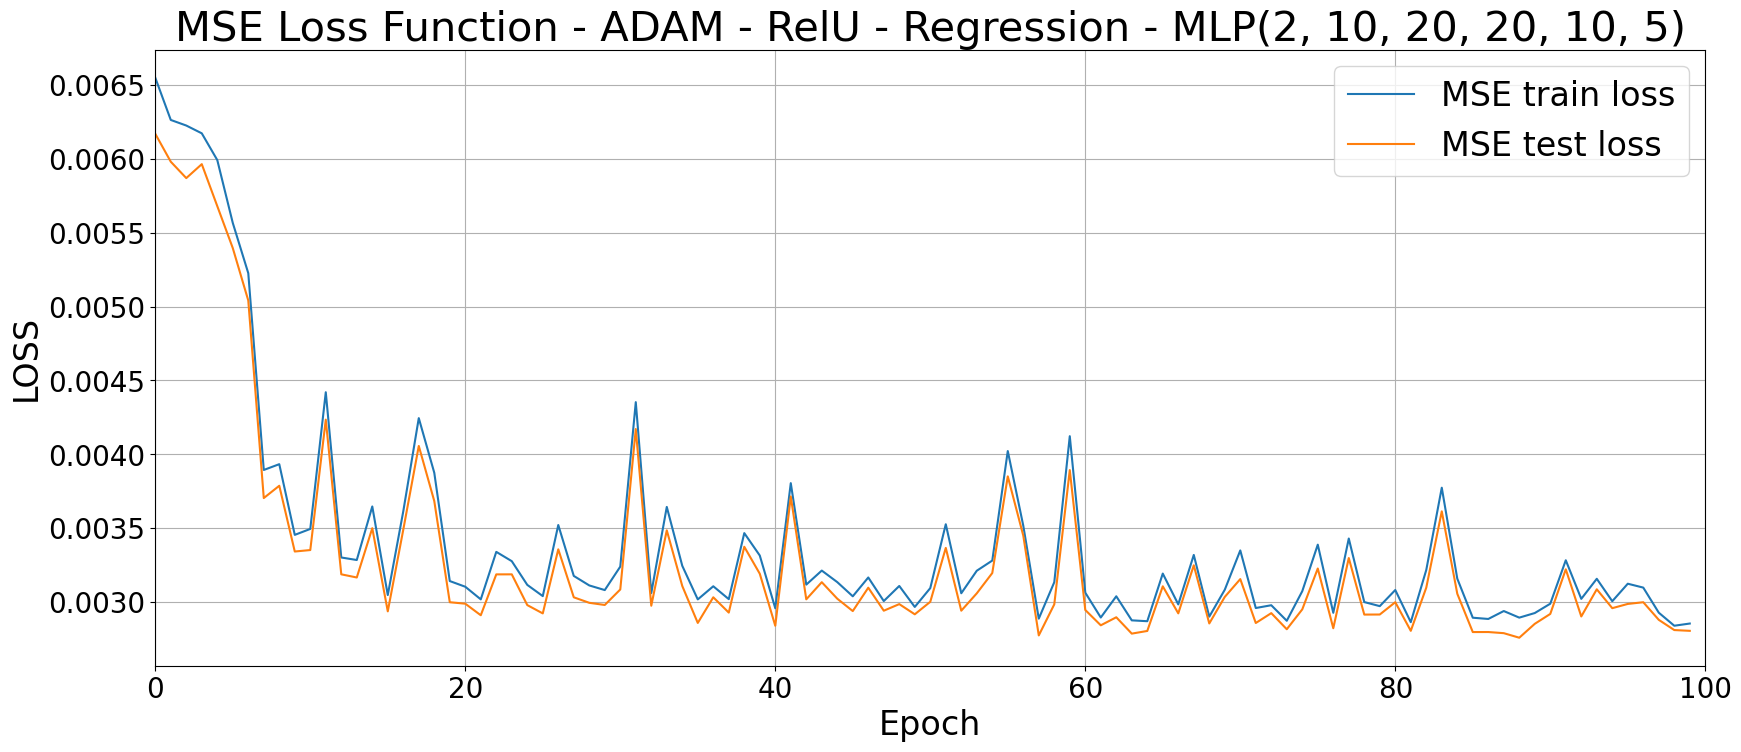

In [113]:
fig, ax = plt.subplots(figsize=(20,8))
ax.set_xlim(0, len(trainingloss))
ax.plot(trainingloss, label='MSE train loss')
ax.plot(testloss, label='MSE test loss')
ax.set_xlabel('Epoch', fontsize=24)
ax.set_ylabel('LOSS', fontsize=24)
ax.legend(fontsize=24)
ax.grid()
ax.set_title("MSE Loss Function - ADAM - RelU - Regression - MLP(2, 10, 20, 20, 10, 5)", fontsize=30)

plt.show()

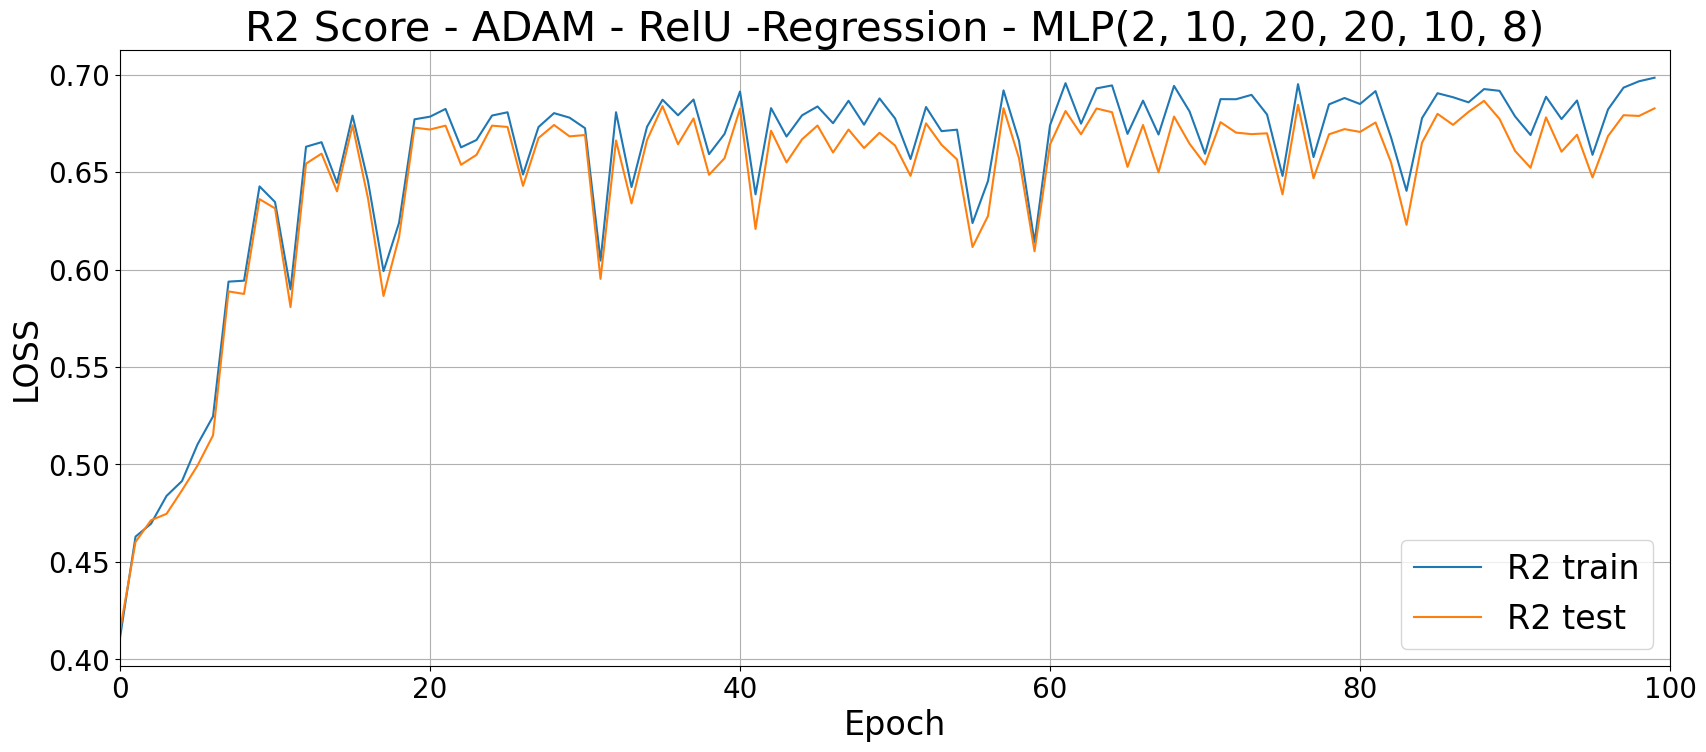

In [114]:
fig, ax = plt.subplots(figsize=(20,8))
ax.set_xlim(0, len(training_R2))
#ax.set_ylim(0, 1)
ax.plot(training_R2, label='R2 train')
ax.plot(test_R2, label='R2 test')
ax.set_xlabel('Epoch', fontsize=24)
ax.set_ylabel('LOSS', fontsize=24)
ax.legend(fontsize=24)
ax.grid()
ax.set_title("R2 Score - ADAM - RelU -Regression - MLP(2, 10, 20, 20, 10, 8)", fontsize=30)

plt.show()

In [115]:
output_model = pd.DataFrame(columns=data.columns)

In [116]:
output_model.loc[0] = [2.75, 0.04, 0, 0, 0, 0, 0, 0, 0, 0]
output_model.loc[1] = [5.5, 0.04, 0, 0, 0, 0, 0, 0, 0, 0]
output_model

,usablegc,usablevc,density,porosity,Ri,SSA,SPV,du,metalw,metala
0,2.75,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5.50,0.04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [117]:
def salida_real(x_real):
    X_real_scaled = escaler_X.transform(x_real)
    y_predict_scaled = model(torch.tensor(X_real_scaled, dtype=torch.float32)).detach().numpy() 
    return escaler_y.inverse_transform(y_predict_scaled)

In [118]:
output_model.iloc[:, 2:] = salida_real(np.array(output_model.iloc[:, :2]))
output_model

,usablegc,usablevc,density,porosity,Ri,SSA,SPV,du,metalw,metala
0,2.75,0.04,1.217370,0.591923,7.834454,1618.775391,0.047326,-80.374382,72.845299,30.187555
1,5.50,0.04,0.043853,0.827760,12.012213,5012.530762,1.641569,240.102585,29.156315,11.141269


In [119]:
np.array(test_R2).max()

np.float64(0.6865876317024231)

In [121]:
np.array(training_R2).max()

np.float64(0.6984521150588989)